In [181]:
import random
import sys
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import skfuzzy as fuzz
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons

from pathlib import Path


PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "components").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "components").exists():
            PROJECT_ROOT = parent
            break
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from components.models import ANFISSimple, fcm_initialize

In [182]:
# ---------------------------
# 1) Preparing the data
# ---------------------------

X, y = make_moons(n_samples=2000, noise=0.2, random_state=42)
X = X.astype(np.float32)
y = y.astype(np.int64)     # labels 0/1

# seperate train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

In [183]:
# ---------------------------
# 5) Training (RMSE + BCE)
# ---------------------------

# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Convert labels
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)
y_test_tensor  = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(1).to(device)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test_tensor  = torch.tensor(X_test,  dtype=torch.float32).to(device)

# Initialization
K = 3
centers_init, spreads_init = fcm_initialize(X_train, K)

# Model
model = ANFISSimple(centers_init, spreads_init).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.BCEWithLogitsLoss()   # logits version

n_epochs = 1000
best_loss = float("inf")
best_state = None

for epoch in range(1, n_epochs + 1):
    model.train()
    optimizer.zero_grad()

    # Forward logits
    y_pred_train_logits = model(X_train_tensor)

    # BCE loss (logits)
    loss = loss_fn(y_pred_train_logits, y_train_tensor)

    # Backprop
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
    optimizer.step()

    # Track best model
    if loss.item() < best_loss:
        best_loss = loss.item()
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    # Logging every 50 epochs
    if epoch % 100 == 0 or epoch == 1:
        model.eval()
        with torch.no_grad():
            train_prob = torch.sigmoid(model(X_train_tensor))
            test_prob  = torch.sigmoid(model(X_test_tensor))

            train_pred = (train_prob >= 0.5).float()
            test_pred = (test_prob >= 0.5).float()

            train_total = y_train_tensor.numel()
            test_total = y_test_tensor.numel()
            train_correct = int((train_pred == y_train_tensor).sum().item())
            test_correct = int((test_pred == y_test_tensor).sum().item())
            train_acc = train_correct / train_total
            test_acc = test_correct / test_total
            train_err = 1.0 - train_acc
            test_err = 1.0 - test_acc

        print(
            f"Epoch {epoch}/{n_epochs}  Loss={loss.item():.4f}  "
            f"Train Acc={train_acc:.3f} (Err {train_err:.3f})  "
            f"Test Acc={test_acc:.3f} (Err {test_err:.3f})"
        )

# Restore best model
if best_state is not None:
    model.load_state_dict(best_state)
model.eval()


# ---------------------------
# 6) Final Evaluation (RMSE)
# ---------------------------
with torch.no_grad():
    final_train_prob = torch.sigmoid(model(X_train_tensor)).cpu().numpy().reshape(-1)
    final_test_prob  = torch.sigmoid(model(X_test_tensor)).cpu().numpy().reshape(-1)


def summarize_split(name, probs, labels):
    preds = (probs >= 0.5).astype(np.int64)
    total = len(labels)
    correct = int((preds == labels).sum())
    wrong = total - correct
    accuracy = correct / total
    error = wrong / total
    print(
        f"{name}: accuracy rate {accuracy:.3f} ({correct}/{total} correct points) | "
        f"error {error:.3f} ({wrong} wrong points)"
    )


print("\nFinal Results:")
summarize_split("Train", final_train_prob, y_train)
summarize_split("Test", final_test_prob, y_test)

Epoch 1/1000  Loss=0.6815  Train Acc=0.786 (Err 0.214)  Test Acc=0.772 (Err 0.228)
Epoch 100/1000  Loss=0.6228  Train Acc=0.811 (Err 0.189)  Test Acc=0.823 (Err 0.177)
Epoch 200/1000  Loss=0.5620  Train Acc=0.827 (Err 0.173)  Test Acc=0.840 (Err 0.160)
Epoch 300/1000  Loss=0.5014  Train Acc=0.844 (Err 0.156)  Test Acc=0.865 (Err 0.135)
Epoch 400/1000  Loss=0.4483  Train Acc=0.863 (Err 0.137)  Test Acc=0.877 (Err 0.123)
Epoch 500/1000  Loss=0.4067  Train Acc=0.868 (Err 0.132)  Test Acc=0.882 (Err 0.118)
Epoch 600/1000  Loss=0.3755  Train Acc=0.874 (Err 0.126)  Test Acc=0.885 (Err 0.115)
Epoch 700/1000  Loss=0.3517  Train Acc=0.880 (Err 0.120)  Test Acc=0.882 (Err 0.118)
Epoch 800/1000  Loss=0.3313  Train Acc=0.887 (Err 0.113)  Test Acc=0.892 (Err 0.108)
Epoch 900/1000  Loss=0.3095  Train Acc=0.895 (Err 0.105)  Test Acc=0.897 (Err 0.103)
Epoch 1000/1000  Loss=0.2782  Train Acc=0.912 (Err 0.088)  Test Acc=0.910 (Err 0.090)

Final Results:
Train: accuracy rate 0.912 (1460/1600 correct poin

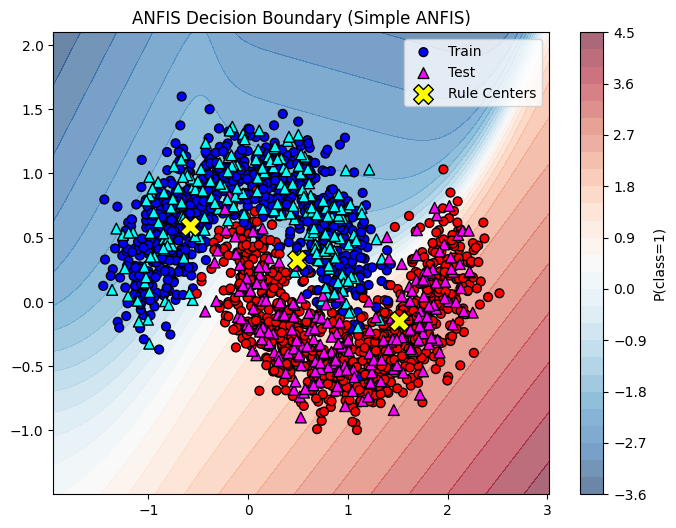

In [184]:
# ---------------------------
# 7: Plot decision boundary (Simple ANFIS)
# ---------------------------
plt.figure(figsize=(8, 6))

# Grid for visualization
xx, yy = np.meshgrid(
    np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 300),
    np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
grid_tensor = torch.from_numpy(grid).to(device)

with torch.no_grad():
    prob_grid = model(grid_tensor).cpu().numpy().reshape(xx.shape)

# Decision boundary contour
contour = plt.contourf(xx, yy, prob_grid, levels=30, cmap="RdBu_r", alpha=0.6)
plt.colorbar(contour, label="P(class=1)")

# Training data
plt.scatter(
    X_train[:, 0], X_train[:, 1], 
    c=y_train, cmap="bwr", edgecolor="k", s=40, label="Train"
)

# Test data
plt.scatter(
    X_test[:, 0], X_test[:, 1], 
    c=y_test, cmap="cool", edgecolor="k", s=60, marker="^", label="Test"
)

# Optional: show rule centers
plt.scatter(
    centers_init[:, 0], centers_init[:, 1],
    c="yellow", s=200, edgecolor="black", marker="X",
    label="Rule Centers"
)

plt.title("ANFIS Decision Boundary (Simple ANFIS)")
plt.legend()
plt.show()
